# Preface

In this notebook, we introduce basic linear models for regression and classification. We will use basic functionalities of the machine learning library `scikit-learn`. Install this by
```
$pip install scikit-learn
```
Documentation is found [here](https://scikit-learn.org/stable/).

We will also need `pandas`, `numpy` and plotting libraries `matplotlib` and `seaborn`.
```
$pip install numpy pandas matplotlib seaborn
```

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")
np.random.seed(135)  # For reproducibility

# Singapore Housing Dataset

This dataset is obtained from a [Govtech database](https://data.gov.sg). Read the description in the website for more information. We are going to only use a subset of this data as a simple demonstration.

## Load Data

The data has been downloaded into the repository for convenience. You also also get this (and more) [here](https://data.gov.sg/dataset/resale-flat-prices). We will only use the dataset `resale-flat-prices-based-on-registration-date-from-jan-2017-onwards.csv` in this simple demo. Besure to place the data in a directory `data/` relative to the directory of this notebook. 

In [5]:
raw_dataset = pd.read_csv('./ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

In [6]:
raw_dataset.head(n=7)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
5,2017-01,ANG MO KIO,3 ROOM,150,ANG MO KIO AVE 5,01 TO 03,68.0,New Generation,1981,63 years,275000.0
6,2017-01,ANG MO KIO,3 ROOM,447,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1979,61 years 06 months,280000.0


## Preprocess Data

Some data should be numerical but we can't easily work with them, so let's do some preprocessing.

In [7]:
def convert_to_years(years_and_months):
    """
    Convert n years m months to (n + m/12) years
    
    Also checkout the datetime package for more general usage
    https://docs.python.org/3/library/datetime.html
    """
    split = years_and_months.split(' ')
    if len(split) == 2:
        return float(split[0])
    elif len(split) == 4:
        return float(split[0]) + float(split[2]) / 12.0
    else:
        raise ValueError('Wrong format.')

def average_storey(storey_range):
    """
    Convert n to m to (n+m)/2
    """
    split = storey_range.split(' TO ')
    if len(split) == 2:
        return 0.5 * (float(split[0]) + float(split[1]))
    else:
        raise ValueError('Wrong format.')

dataset = raw_dataset.copy()
dataset['remaining_lease'] = dataset['remaining_lease'].apply(convert_to_years)
dataset['storey'] = dataset['storey_range'].apply(average_storey)

In [8]:
dataset.head(n=7)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61.333333,232000.0,11.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60.583333,250000.0,2.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62.416667,262000.0,2.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62.083333,265000.0,5.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62.416667,265000.0,2.0
5,2017-01,ANG MO KIO,3 ROOM,150,ANG MO KIO AVE 5,01 TO 03,68.0,New Generation,1981,63.000000,275000.0,2.0
6,2017-01,ANG MO KIO,3 ROOM,447,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1979,61.500000,280000.0,5.0


## Some Visualizations

We will visualize the data to find some patterns. The `seaborn` plotting library has some useful tools to do this.

C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_9328\3591126499.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)
C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_9328\3591126499.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)
C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_9328\3591126499.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)


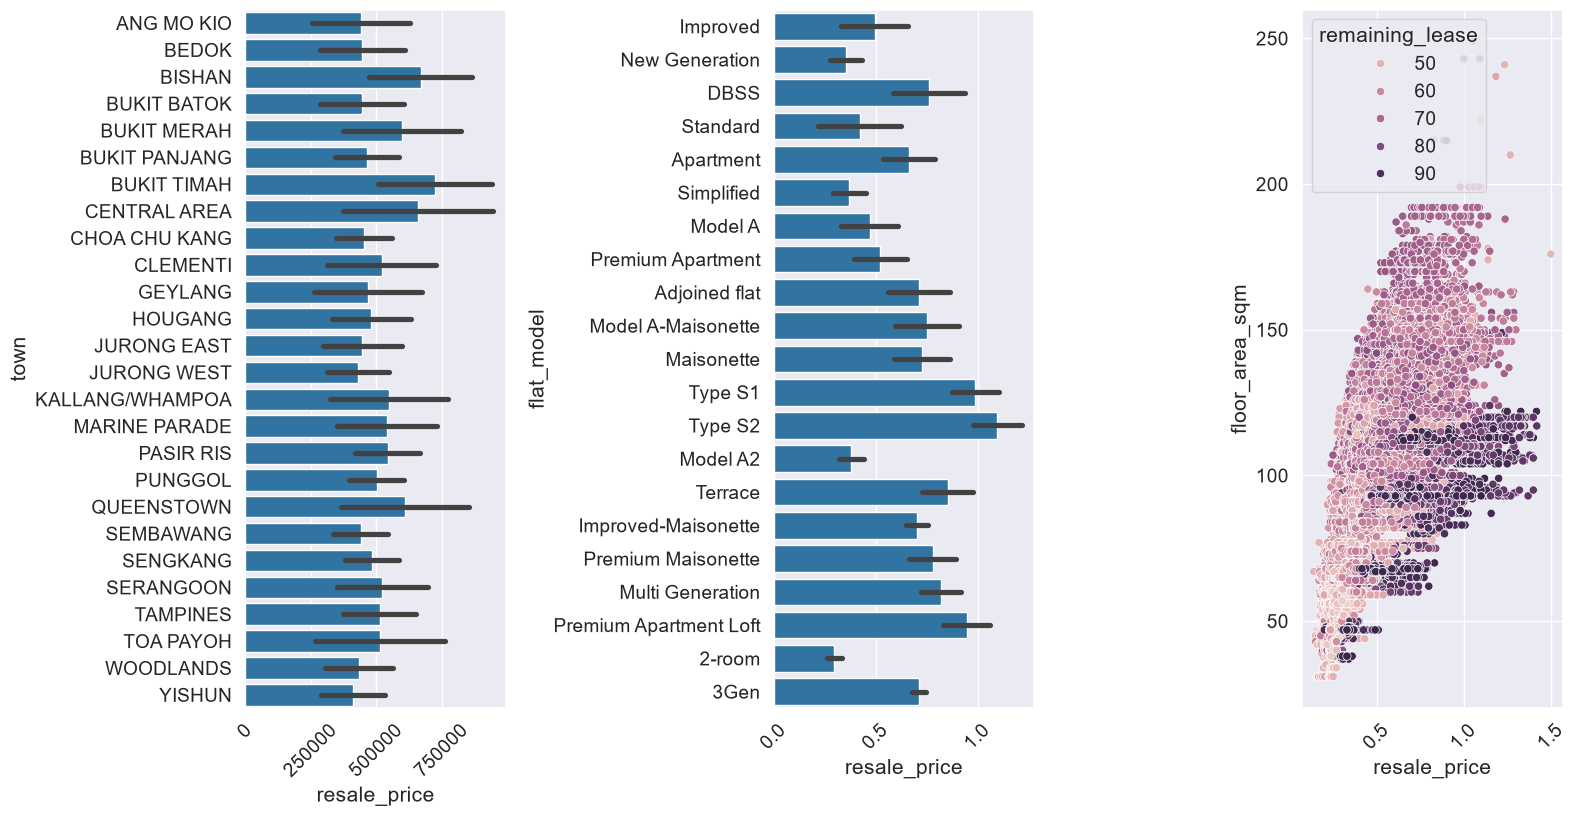

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

sns.barplot(
    x='resale_price',
    y='town',
    data=dataset,
    orient='h',
    errorbar='sd',
    ax=ax[0]
)

sns.barplot(
    x='resale_price',
    y='flat_model',
    data=dataset,
    orient='h',
    errorbar='sd',
    ax=ax[1]
)

sns.scatterplot(
    x='resale_price',
    y='floor_area_sqm',
    hue='remaining_lease',
    data=dataset,
    ax=ax[2]
)

fig.tight_layout()

for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=45)

Let us look at the effect of some other variables.

<Axes: xlabel='resale_price', ylabel='storey'>

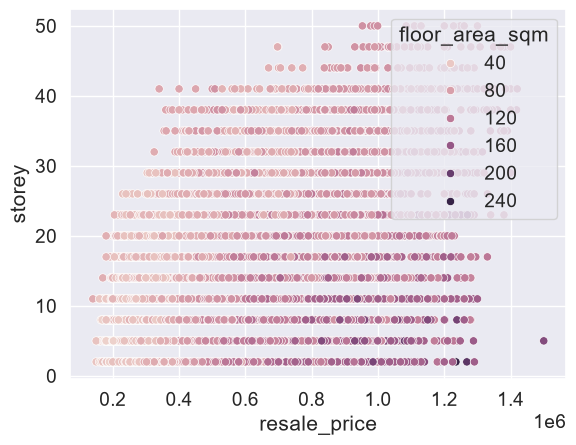

In [10]:
sns.scatterplot(
    x='resale_price',
    y='storey',
    hue='floor_area_sqm',
    data=dataset,
)

## Train Test Split

We will know proceed to fit some models to predict the *resale_price* given some input descriptors. This is a classical regression problem. 

To evaluate our machine learning models, we should have at least 1 hold-out test set that is untouched by our learning algorithm, until evaluation time. Since no hyper-parameter tuning is performed, it is sufficient to keep a single test set for this purpose. We use some handy functions from `sklearn`. 

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
dataset_train, dataset_test = train_test_split(dataset, test_size=0.1)

In [13]:
dataset_train.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey
125491,2022-04,YISHUN,4 ROOM,755,YISHUN ST 72,07 TO 09,84.0,Simplified,1986,63.583333,422000.0,8.0
106572,2021-04,SEMBAWANG,5 ROOM,337,SEMBAWANG CRES,16 TO 18,115.0,Improved,1999,77.333333,455000.0,17.0
73287,2020-07,BUKIT BATOK,4 ROOM,625,BT BATOK CTRL,04 TO 06,103.0,Model A,1997,75.916667,495000.0,5.0
110524,2021-02,TAMPINES,5 ROOM,704,TAMPINES ST 71,10 TO 12,119.0,Improved,1997,75.500000,585000.0,11.0
121877,2022-03,HOUGANG,4 ROOM,572,HOUGANG ST 51,07 TO 09,98.0,Model A,1997,73.916667,510000.0,8.0


In [14]:
dataset_test.head(n=4)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey
81387,2020-10,JURONG WEST,5 ROOM,275C,JURONG WEST ST 25,07 TO 09,111.0,Improved,2002,80.250000,400000.0,8.0
67051,2020-02,PUNGGOL,2 ROOM,601D,PUNGGOL CTRL,01 TO 03,50.0,Model A,2012,91.500000,238000.0,2.0
59799,2019-10,SENGKANG,5 ROOM,196,RIVERVALE DR,13 TO 15,111.0,Improved,2001,80.500000,415000.0,14.0
102061,2021-04,PASIR RIS,EXECUTIVE,780,PASIR RIS ST 71,01 TO 03,144.0,Apartment,1996,74.416667,655000.0,2.0


## Simple Linear Regression

We can see from the visualization that floor area is related to price. Rather, we should know this without seeing any data. We now try to regress the resale price from floor area alone and see how we do. 

Instead of coding our own ordinary least squares solver, `sklearn` (and many other libraries) have ready-made implementations. 

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
inputs = 'floor_area_sqm'
outputs = 'resale_price'

x_train = dataset_train[inputs].to_numpy()[:, np.newaxis]
x_test = dataset_test[inputs].to_numpy()[:, np.newaxis]

y_train = dataset_train[outputs].to_numpy()
y_test = dataset_test[outputs].to_numpy()

In [17]:
regressor = LinearRegression()
regressor.fit(
    X=x_train,
    y=y_train,
)
y_hat_train = regressor.predict(x_train)
y_hat_test = regressor.predict(x_test)

### Visualizing Regression Result

Since we are working in one dimension, it is possible to visualize our linear fit.

Note that the following can be directly reproduced by a single `sns.regplot` call from `seaborn`, without explicitly using `LinearRegression()` from `sklearn`. 

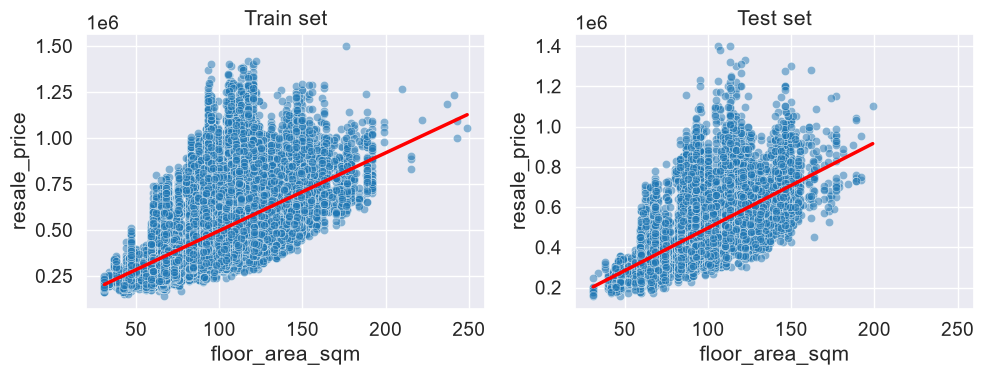

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.scatterplot(
    x=x_train.ravel(),
    y=y_train,
    ax=ax[0],
    alpha=0.5,
)
sns.lineplot(
    x=x_train.ravel(),
    y=y_hat_train,
    ax=ax[0],
    color='red',
)

sns.scatterplot(
    x=x_test.ravel(),
    y=y_test,
    ax=ax[1],
    alpha=0.5,
)
sns.lineplot(
    x=x_test.ravel(),
    y=y_hat_test,
    ax=ax[1],
    color='red',
)



for a in ax:
    a.set_xlabel(inputs)
    a.set_ylabel(outputs)

    
ax[0].set_title('Train set')
ax[1].set_title('Test set')




fig.tight_layout()

Alternatively, we can directly compare our predicted resale prices with the ground truth. This works if we have higher dimensional inputs so that a linear fit is difficult to plot graphically.

In [19]:
y_hat_train.shape

(142563,)

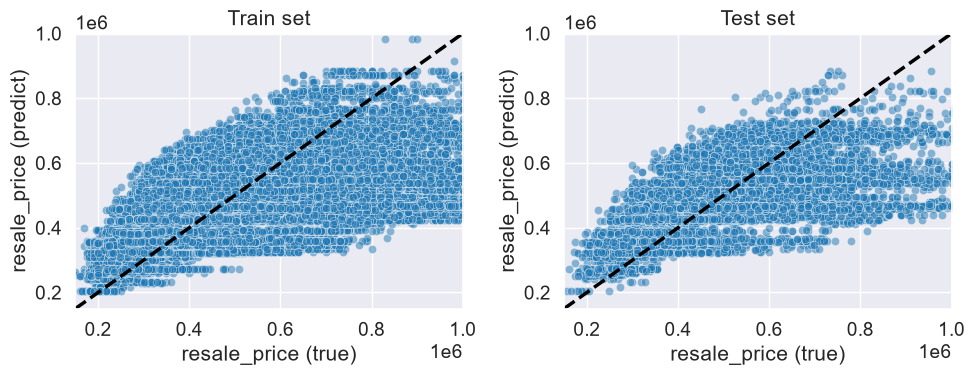

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    x=y_train,
    y=y_hat_train,
    ax=ax[0],
    alpha=0.5,
)

sns.scatterplot(
    x=y_test,
    y=y_hat_test,
    ax=ax[1],
    alpha=0.5,
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predict)')
    a.set_xlim(1.5*10**5, 10**6)
    a.set_ylim(1.5*10**5, 10**6)
    a.plot(a.get_xlim(), a.get_ylim(), ls='--', c='k')


    
ax[0].set_title('Train set')
ax[1].set_title('Test set')

fig.tight_layout()

### Quantifying the Error

Just looking at the fit doesn't tell us very precise information. Therefore, it is often better to quantify the error. One simple metric is the mean-square difference between the predicted outputs and the actual outputs. But this is not the only one! You are encouraged to look at [`sklearn.metrics`](https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics) to find more ways to evaluate the results. 

In [21]:
from sklearn.metrics import mean_squared_error
def rmse_scaled(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    scale = np.sqrt(np.mean(y_true**2))
    return rmse/scale

In [22]:
print(
    f'Scaled RMSE: \n {rmse_scaled(y_train, y_hat_train)} (Train) \
    \n {rmse_scaled(y_test, y_hat_test)} (Test)'
)

Scaled RMSE: 
 0.25927802639159164 (Train)     
 0.26031247429945686 (Test)


## Polynomial Regression

Simple linear regression gave about 26% error. Can we do better by going to larger hypothesis spaces? Let us now try a **polynomial regression** up to degree 3. This is an example of a linear basis model. 

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
x_train[:8]

array([[ 84.],
       [115.],
       [103.],
       [119.],
       [ 98.],
       [ 88.],
       [ 93.],
       [ 93.]])

In [25]:
phi = PolynomialFeatures(degree=3)
x_poly_train = phi.fit_transform(x_train)
x_poly_test = phi.fit_transform(x_test)

In [26]:
regressor_poly = LinearRegression()
regressor_poly.fit(
    X=x_poly_train,
    y=y_train,
)
y_hat_poly_train = regressor_poly.predict(x_poly_train)
y_hat_poly_test = regressor_poly.predict(x_poly_test)

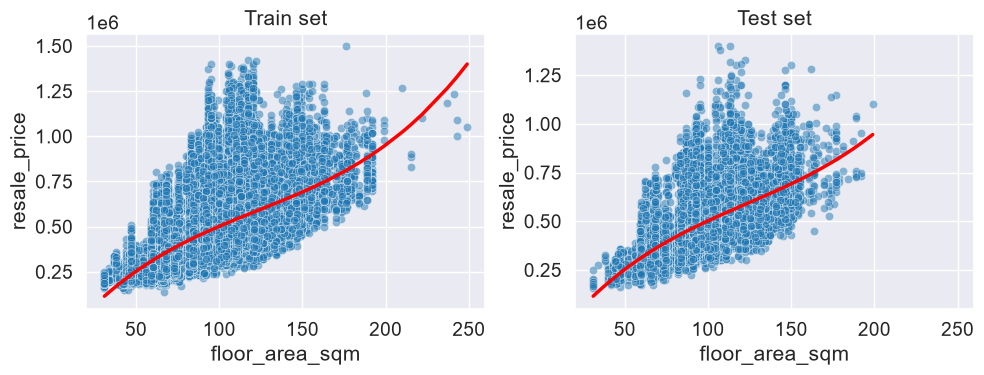

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.scatterplot(
    x=x_train.ravel(),
    y=y_train,
    ax=ax[0],
    alpha=0.5,
)
sns.lineplot(
    x=x_train.ravel(),
    y=y_hat_poly_train,
    ax=ax[0],
    color='red',
)

sns.scatterplot(
    x=x_test.ravel(),
    y=y_test,
    ax=ax[1],
    alpha=0.5,
)
sns.lineplot(
    x=x_test.ravel(),
    y=y_hat_poly_test,
    ax=ax[1],
    color='red',
)



for a in ax:
    a.set_xlabel(inputs)
    a.set_ylabel(outputs)

    
ax[0].set_title('Train set')
ax[1].set_title('Test set')




fig.tight_layout()

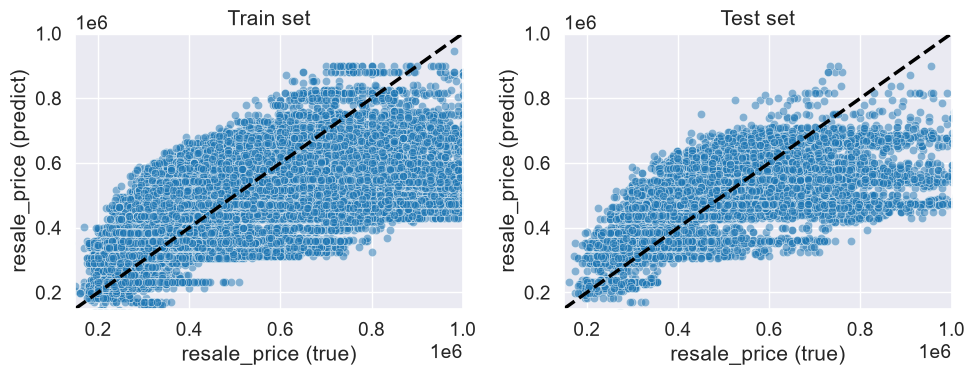

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    x=y_train,
    y=y_hat_poly_train,
    ax=ax[0],
    alpha=0.5,
)

sns.scatterplot(
    x=y_test,
    y=y_hat_poly_test,
    ax=ax[1],
    alpha=0.5,
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predict)')
    a.set_xlim(1.5*10**5, 10**6)
    a.set_ylim(1.5*10**5, 10**6)
    a.plot(a.get_xlim(), a.get_ylim(), ls='--', c='k')


    
ax[0].set_title('Train set')
ax[1].set_title('Test set')

fig.tight_layout()

In [29]:
print(
    f'Scaled RMSE: \n {rmse_scaled(y_train, y_hat_poly_train)} (Train) \
    \n {rmse_scaled(y_test, y_hat_poly_test)} (Test)'
)

Scaled RMSE: 
 0.25868431565800204 (Train)     
 0.2598028468707323 (Test)


Looks like polynomial regression didn't really improve on the simple linear regression result. Why?

## Including More Design Variables in Linear Regression

Clearly, the size of the house is not the only factor determining price. Let us now include some other factors which may contribute. In this case, the regression problem is defined in higher dimenions.

Note that from the viewpoint of approximation, we are also using a bigger **hypothesis space**, but not in the same way as a polynomial basis in one dimension. In the first linear regression example, we are using the hypothesis space consisting of all functions which are affine in *floor_area_sqm* and constant in the other dependent variables. Now, we are using the hypothesis space consisting of affine functions of more than one variable.

In [30]:
dataset.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61.333333,232000.0,11.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60.583333,250000.0,2.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62.416667,262000.0,2.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62.083333,265000.0,5.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62.416667,265000.0,2.0


In [31]:
inputs = ['town', 'floor_area_sqm', 'remaining_lease', 'storey']
outputs = 'resale_price'

In [32]:
x_train = dataset_train[dataset_train.columns.intersection(inputs)]
x_train.head()

,town,floor_area_sqm,remaining_lease,storey
125491,YISHUN,84.0,63.583333,8.0
106572,SEMBAWANG,115.0,77.333333,17.0
73287,BUKIT BATOK,103.0,75.916667,5.0
110524,TAMPINES,119.0,75.500000,11.0
121877,HOUGANG,98.0,73.916667,8.0


Note that the "town" column are nominal/categorical variables, so let us perform a **one-hot encoding**. 

In [33]:
x_train = pd.get_dummies(x_train)
y_train = dataset_train[outputs]
x_train.head()

,floor_area_sqm,remaining_lease,storey,town_ANG MO KIO,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,town_BUKIT TIMAH,...,town_PASIR RIS,town_PUNGGOL,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN
125491,84.0,63.583333,8.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
106572,115.0,77.333333,17.0,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
73287,103.0,75.916667,5.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
110524,119.0,75.500000,11.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
121877,98.0,73.916667,8.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


we repeat this for the test set

In [34]:
x_test = dataset_test[dataset_test.columns.intersection(inputs)]
x_test = pd.get_dummies(x_test)
y_test = dataset_test[outputs]

now we train the regressor in these new variables

In [35]:
regressor = LinearRegression()
regressor.fit(
    X=x_train,
    y=y_train,
)
y_hat_train = regressor.predict(x_train)
y_hat_test = regressor.predict(x_test)

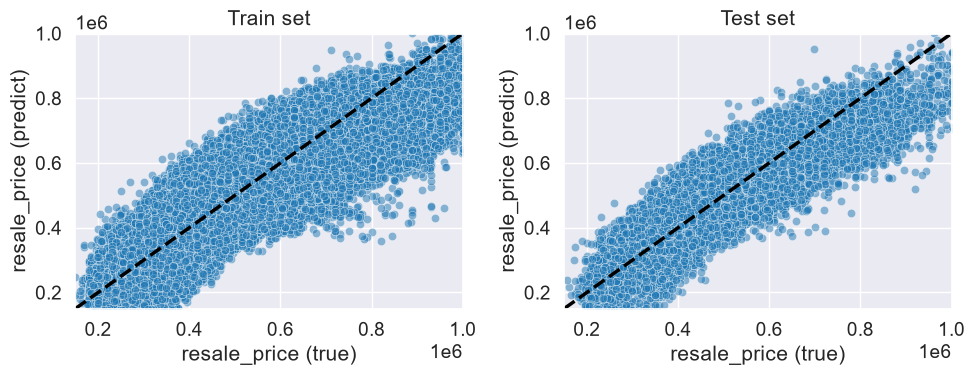

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    x=y_train,
    y=y_hat_train,
    ax=ax[0],
    alpha=0.5,
)

sns.scatterplot(
    x=y_test,
    y=y_hat_test,
    ax=ax[1],
    alpha=0.5,
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predict)')
    a.set_xlim(1.5*10**5, 10**6)
    a.set_ylim(1.5*10**5, 10**6)
    a.plot(a.get_xlim(), a.get_ylim(), ls='--', c='k')


    
ax[0].set_title('Train set')
ax[1].set_title('Test set')

fig.tight_layout()

In [37]:
print(
    f'Scaled RMSE: \n {rmse_scaled(y_train, y_hat_train)} (Train) \
    \n {rmse_scaled(y_test, y_hat_test)} (Test)'
)

Scaled RMSE: 
 0.16262618789000477 (Train)     
 0.16286074637590534 (Test)


Observe from the fit and the RMSE that we are doing quite a bit better than the univariate linear case. Can you improve on this:
  *  Better accuracy?
  *  Smaller number of features?

One thing we can try is quadratic regression on the same input variables.

In [38]:
phi =  PolynomialFeatures(degree=2)
x_mult_poly_train = phi.fit_transform(x_train)
x_mult_poly_test = phi.fit_transform(x_test)

In [39]:
regressor_poly = LinearRegression()
regressor_poly.fit(
    X=x_mult_poly_train,
    y=y_train,
)
y_hat_mult_poly_train = regressor_poly.predict(x_mult_poly_train)
y_hat_mult_poly_test = regressor_poly.predict(x_mult_poly_test)

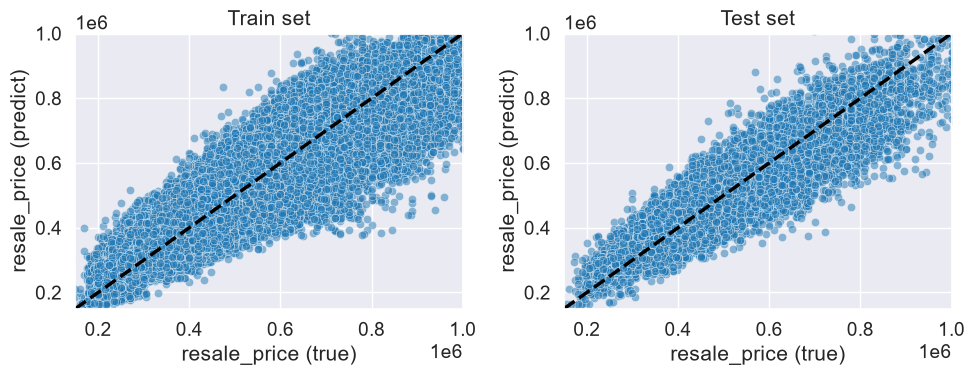

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    x=y_train,
    y=y_hat_mult_poly_train,
    ax=ax[0],
    alpha=0.5,
)

sns.scatterplot(
    x=y_test,
    y=y_hat_mult_poly_test,
    ax=ax[1],
    alpha=0.5,
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predict)')
    a.set_xlim(1.5*10**5, 10**6)
    a.set_ylim(1.5*10**5, 10**6)
    a.plot(a.get_xlim(), a.get_ylim(), ls='--', c='k')


    
ax[0].set_title('Train set')
ax[1].set_title('Test set')

fig.tight_layout()

In [41]:
print(
    f'Scaled RMSE: \n {rmse_scaled(y_train, y_hat_mult_poly_train)} (Train) \
    \n {rmse_scaled(y_test, y_hat_mult_poly_test)} (Test)'
)

Scaled RMSE: 
 0.14337981235509226 (Train)     
 0.1435305383127177 (Test)


# Digits Classification

Let us now turn to a simple classification problem and apply linear models. This is a digit recognition problem on the [MNIST dataset](http://yann.lecun.com/exdb/mnist/)

We aim to classify hand-written digits from 0-9 using a linear classifier. Let us first load the dataset and display some images.

In [42]:
from sklearn.datasets import fetch_openml
#x, y = fetch_openml('mnist_784', return_X_y=True)
x, y = fetch_openml('mnist_784', version=1, return_X_y=True, data_home='./')
#y = y.astype(int)

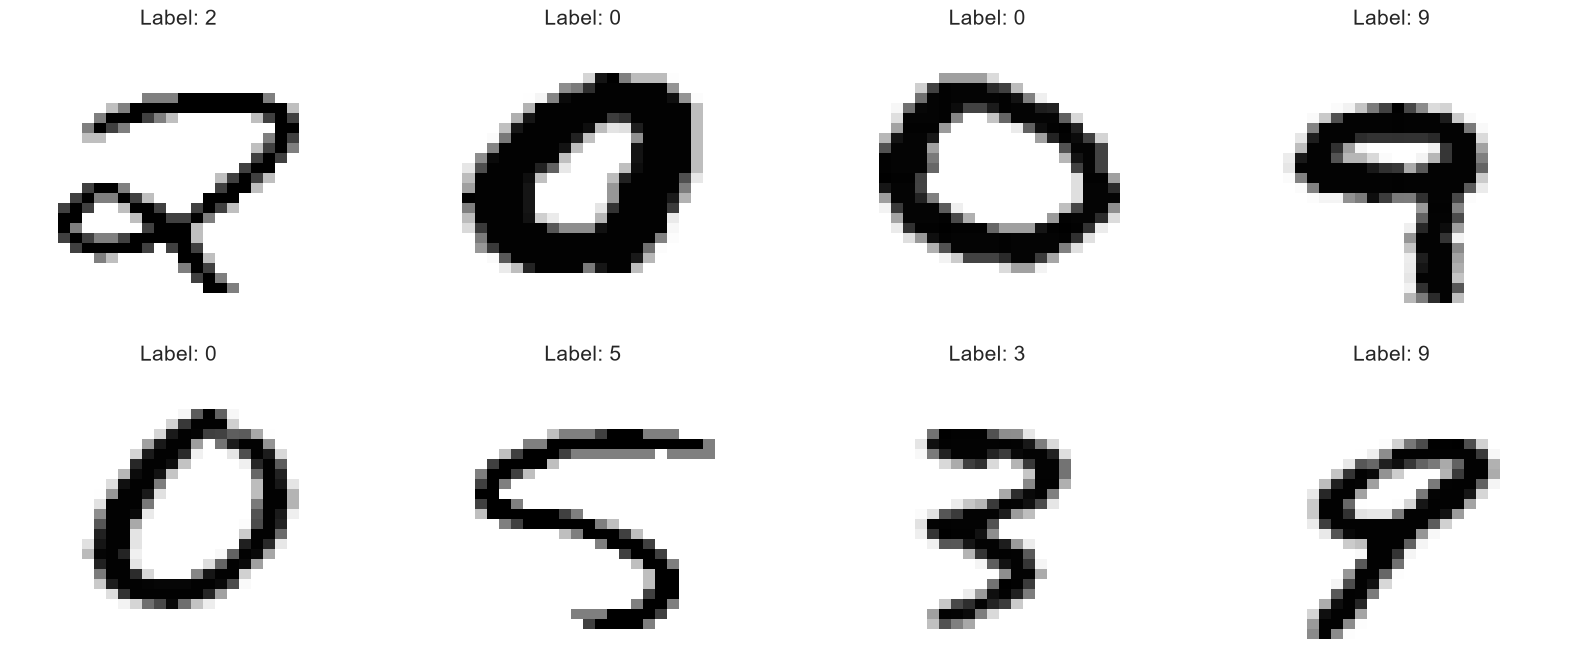

In [43]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8))
for a in ax.ravel():
    j = np.random.choice(len(y))
    sns.heatmap(x.to_numpy()[j].reshape(28,28), ax=a, cbar=False, cmap='gray_r')
    a.set_title(f'Label: {y[j]}')
    a.set_xticks([])
    a.set_yticks([])

## Fit a Linear Classifier

We fit a linear classifier with softmax-crossentropy loss. 

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=5000)
x_train /= 255.0
x_test /= 255.0

We will optimize the linear model using the [L-BFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS) solver. For larger scale problems this is typically inefficient and we will learn more tools based on **stochastic gradient algorithms** later on in the course. We can also ignore the warning of non-convergence since in this task an accurate minimization of the loss function is not necessary to make good predictions on the test set.

In [46]:
clf = LogisticRegression(
    solver='lbfgs',
)

In [47]:
clf.fit(x_train, y_train)

c:\Users\YuxinLi\anaconda3\envs\DSA5102\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Evaluating our Classifier

How do we evaluate our results? The simplest metric is the accuracy.

In [48]:
y_hat_train = clf.predict(x_train)
y_hat_test = clf.predict(x_test)

print(
    f'Train Accuracy: {(y_hat_train == y_train).mean()} \
    \n Test Accuracy: {(y_hat_test == y_test).mean()}'
)

Train Accuracy: 0.9349384615384615     
 Test Accuracy: 0.9236


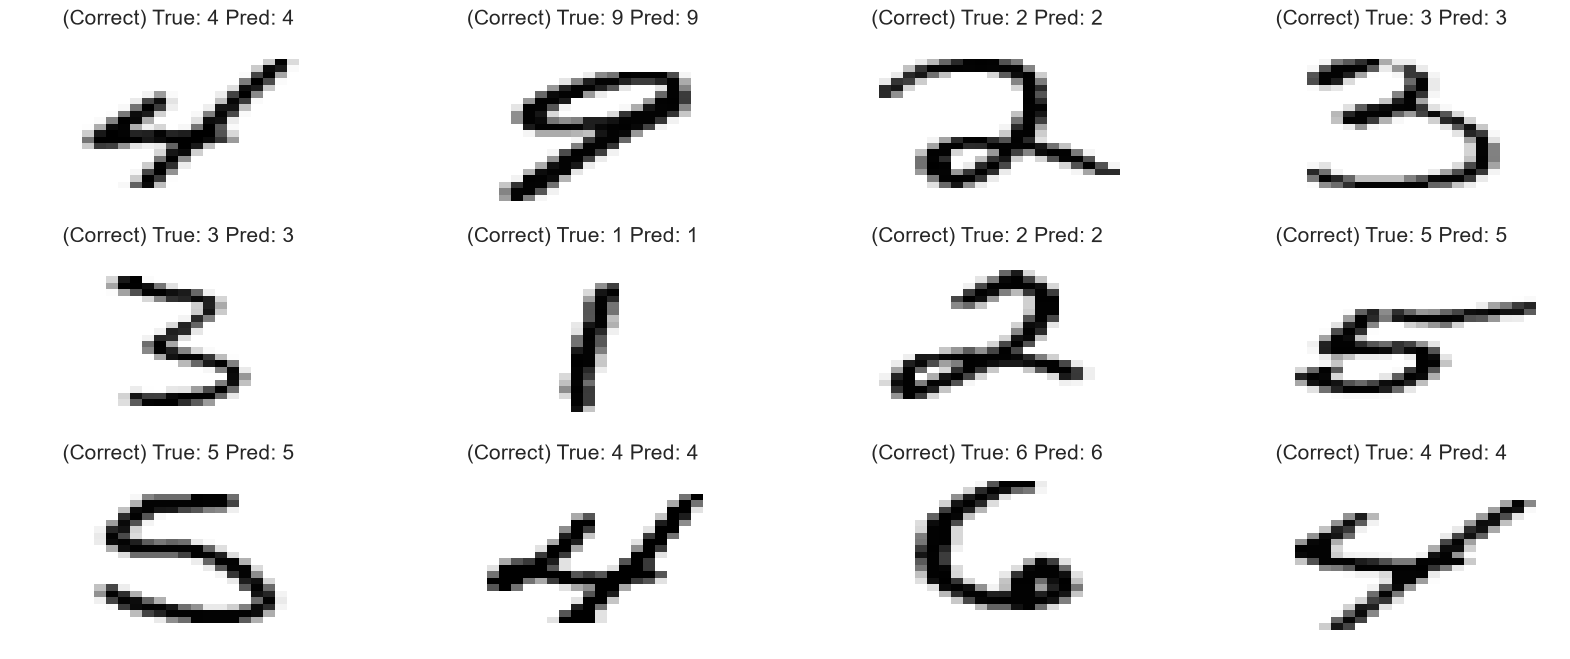

In [49]:
fig, ax = plt.subplots(3, 4, figsize=(20, 8))
result_dict = {True: '(Correct)', False: '(Wrong)'}
for a in ax.ravel():
    j = np.random.choice(len(y_test))
    sns.heatmap(x_test.to_numpy()[j].reshape(28,28), ax=a, cbar=False, cmap='gray_r')
    result = y_test.to_numpy()[j] == y_hat_test[j]
    a.set_title(f'{result_dict[result]} True: {y_test.to_numpy()[j]} Pred: {y_hat_test[j]}')
    a.set_xticks([])
    a.set_yticks([])

What did we tend to get wrong? Another useful checking tool is the **confusion matrix** $M$. Each row of $M$ is the predicted class and each column of $M$ is the actual class. Therefore
$$
    M_{ij} = \text{Number of samples with class } j \text{ that is predicted to be class } i
$$
A larger number of confusions between two classes signify typically that the ML algorithm to separate them needs to be improved.

In [50]:
from sklearn.metrics import confusion_matrix

[[480   0   3   1   1   1   5   0   1   2]
 [  0 549   2   0   0   1   0   2   6   2]
 [  2   8 427   7   4   1   9   6  12   1]
 [  2   4   9 479   0  19   1   6  13   6]
 [  1   1   7   1 471   0   2   1   5  15]
 [  3   4   3  25   3 383   7   4  17   6]
 [  6   2   4   1   2   8 494   1   2   1]
 [  0   4   4   1   1   0   0 490   0  15]
 [  2   9   5  12   3   5   3   5 388   4]
 [  3   2   3   4  12   2   0  11   3 457]]


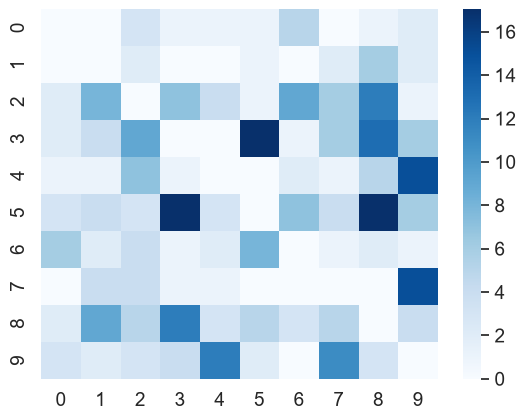

In [51]:
M = confusion_matrix(y_test, y_hat_test)
print(M)
sns.heatmap(M - np.diag(np.diag(M)), robust=True, cmap=plt.cm.Blues);  # We will remove the diagonal for clearer view